In [2]:
import seaborn as sns
import pandas as pd

# Le dataset Titanic : un passager par ligne, a-t-il survécu ou non
df = sns.load_dataset("titanic")

# .dtypes donne le type technique de chaque colonne (int, float, object...)
print(df.dtypes)
print("\nForme (lignes, colonnes) :", df.shape)
print("\nAperçu :")
print(df[["survived", "sex", "age", "pclass", "fare", "embarked"]].head())

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Forme (lignes, colonnes) : (891, 15)

Aperçu :
   survived     sex   age  pclass     fare embarked
0         0    male  22.0       3   7.2500        S
1         1  female  38.0       1  71.2833        C
2         1  female  26.0       3   7.9250        S
3         1  female  35.0       1  53.1000        S
4         0    male  35.0       3   8.0500        S


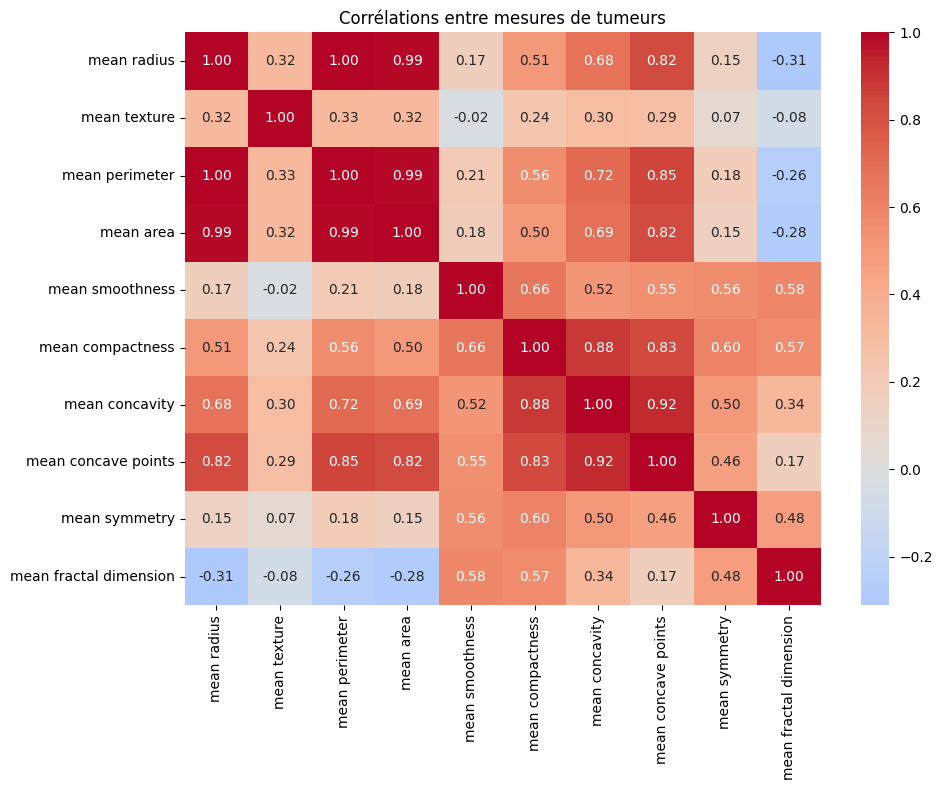

In [3]:
from sklearn.datasets import load_breast_cancer
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = load_breast_cancer(as_frame=True)
df = data.frame

# On regarde les 10 premières mesures pour que la carte reste lisible
cols = data.feature_names[:10]
matrice = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matrice, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations entre mesures de tumeurs")
plt.tight_layout()
plt.show()


In [53]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Fichiers disponibles :", os.listdir(path))

#df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
df = pd.read_csv(r"C:\Users\Math34\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Forme :", df.shape)
df.head()

Fichiers disponibles : ['WA_Fn-UseC_-Telco-Customer-Churn.csv']
Forme : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
import numpy as np 

def audit_qualite(df):
    """Affiche un rapport de santé du dataset.
    Doit montrer : forme, types, % de manquants par colonne (triés),
    et la répartition de la cible Churn (en valeur ET en pourcentage).
    """
    print("Forme :", df.shape)
    print((df.isna().mean().sort_values(ascending=False) * 100).round(2).astype(str) + "%")
    print(df["Churn"].value_counts())
    print(df["Churn"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

    # TODO : afficher la forme (lignes, colonnes)
    # TODO : pour chaque colonne, le pourcentage de valeurs manquantes, trié décroissant
    # TODO : la répartition de la cible Churn en nombre et en %

audit_qualite(df)

In [ ]:
def reparer_total_charges(df):
    """Convertit TotalCharges en numérique et traite les trous révélés.
    Doit renvoyer le df réparé et afficher combien de trous ont été démasqués.
    """
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    print(df.isna().mean().sort_values(ascending=False))
    
    # TODO : convertir TotalCharges en numérique (pd.to_numeric, errors="coerce"
    # transforme les valeurs illisibles en NaN)
    # TODO : compter et afficher combien de NaN sont apparus
    # TODO : imputer ces trous (médiane) ou décider de supprimer ces lignes : justifiez
    pass

In [ ]:
def reparer_total_charges(df):
    """Convertit TotalCharges en numérique et traite les trous révélés.
    Doit renvoyer le df réparé et afficher combien de trous ont été démasqués.
    """
    df = df.copy()

    avant = pd.to_numeric(df["TotalCharges"], errors="coerce").dropna()
    print(f"Avant  : moyenne={avant.mean():.1f}, écart-type={avant.std():.1f}")

    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    n_trous = df["TotalCharges"].isna().sum()
    print(f"\nTrous démasqués après conversion : {n_trous}")

    # Inspecter les lignes concernées pour comprendre POURQUOI c'est manquant
    masque = df["TotalCharges"].isna()
    print("\nLignes avec TotalCharges manquant :")
    print(df[masque][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]])
    print("\nValeurs de tenure uniques sur ces lignes :", df[masque]["tenure"].unique())

    # Vérifier que tenure=0 n'est présent que lorsque TotalCharges est null 
    tenure_zero = df[df["tenure"] == 0]
    print(f"\nLignes avec tenure=0 : {len(tenure_zero)}")
    print(f"  Dont TotalCharges NaN    : {tenure_zero['TotalCharges'].isna().sum()}")
    print(f"  Dont TotalCharges valide : {tenure_zero['TotalCharges'].notna().sum()}")
    if tenure_zero["TotalCharges"].isna().sum() == n_trous and tenure_zero["TotalCharges"].notna().sum() == 0:
        print("  → Relation parfaite : tenure=0 explique exactement tous les trous.")
    else:
        print("  → Relation imparfaite : d'autres facteurs expliquent les trous, creuser avant d'imputer.")

    # Toutes ont tenure=0 : trous structurels,
    # trop peu (11) pour supprimer, imputation par médiane safe.
    mediane = df["TotalCharges"].median()
    df["TotalCharges"] = df["TotalCharges"].fillna(mediane)

    print(f"\nAprès  : moyenne={df['TotalCharges'].mean():.1f}, écart-type={df['TotalCharges'].std():.1f}")
    print(f"Valeur imputée (médiane) : {mediane:.1f}")

    pass

df = reparer_total_charges(df)


Avant  : moyenne=2283.3, écart-type=2266.8

Trous démasqués après conversion : 11

Lignes avec TotalCharges manquant :
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN

Valeurs de tenure uniques sur ces lignes : [0]

Lignes avec tenure=0 : 11
  Dont TotalCharges NaN    : 11
  Dont TotalCharges valide : 0
  → Relation parfaite : tenure=0 explique exactement tous les trous.

Après  : moye

In [54]:
from sklearn.preprocessing import OrdinalEncoder

def encoder_features(df):
    """Encode toutes les colonnes catégorielles.
    Doit renvoyer un df 100% numérique, prêt pour un modèle.
    """
    df = df.copy()

    # customerID : identifiant unique, pas une feature, je l'enlève. 
    # un identifiant n'apporte aucun signal prédictif mais noie le modèle dans du bruit. Plus explosion des dimensions. 
    # ADVERSARIAL catégorie ultra-rare : si une modalité n'apparaît que chez 1 seul client,
    # get_dummies crée quand même une colonne entière remplie de 0 sauf 1 ligne.
    # Le modèle ne peut rien apprendre de cette colonne (trop peu d'exemples),
    # En pratique : regrouper les rares dans une catégorie "Autre" avant d'encoder, ou filtrer/supprimer les modalités sous un seuil minimum.
    df = df.drop(columns=["customerID"])

    # TotalCharges : peut rester object si reparer_total_charges n'a pas tourné avant
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    cols_binaires = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
    for col in cols_binaires:
        df[col] = df[col].map({"Yes": 1, "No": 0})

    df["gender"] = df["gender"].map({"Female": 0, "Male": 1})

    # Contract : ORDINAL, pas nominal.
    # Argument : les 3 modalités ont un ordre naturel de durée d'engagement croissante :
    #   Month-to-month (0) < One year (1) < Two year (2)
    # Coder en One-Hot effacerait cette information d'ordre et créerait 3 colonnes redondantes.
    # OrdinalEncoder préserve l'ordre ET reste compact (1 seule colonne).
    enc = OrdinalEncoder(categories=[["Month-to-month", "One year", "Two year"]])
    df["Contract"] = enc.fit_transform(df[["Contract"]]).astype(int)

    # Nominales multi-catégories → One-Hot (pas d'ordre à inventer)
    cols_onehot = [
        "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
        "PaymentMethod"
    ]
    df = pd.get_dummies(df, columns=cols_onehot)

    print(f"Colonnes avant : 21  →  après : {df.shape[1]}")
    print(f"Colonnes encore en object : {list(df.select_dtypes('object').columns)}")

    return df

df_encoded = encoder_features(df)
df_encoded.head()


Colonnes avant : 21  →  après : 39
Colonnes encore en object : []


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,1,0,56.95,1889.50,...,True,False,False,True,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,53.85,108.15,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,1,0,42.30,1840.75,...,True,False,False,True,False,False,True,False,False,False
4,0,0,0,0,2,1,0,1,70.70,151.65,...,True,False,False,True,False,False,False,False,True,False


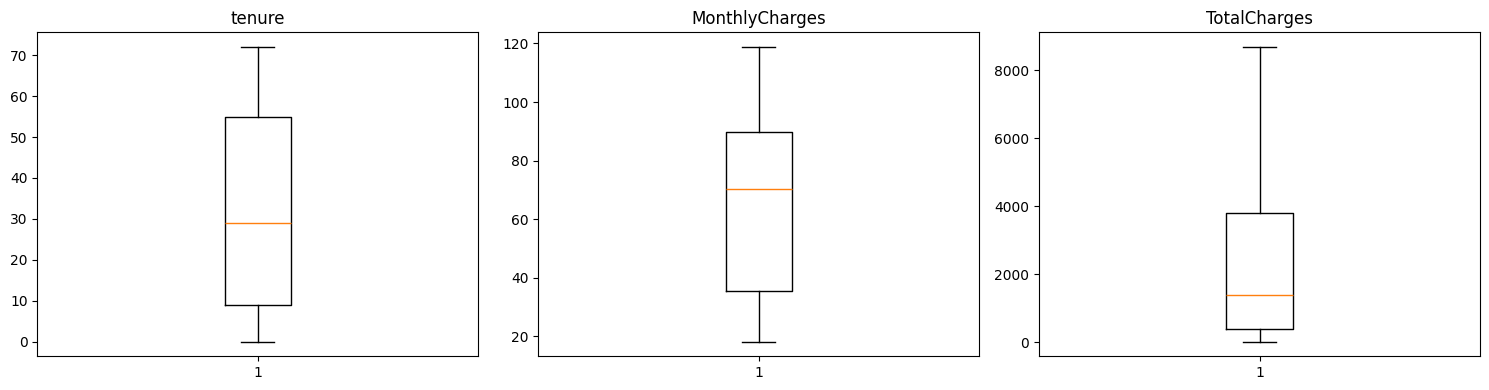

Colonne               Borne basse  Borne haute  Nb outliers
------------------------------------------------------------
tenure                      -60.0        124.0            0
MonthlyCharges              -46.0        171.4            0
TotalCharges              -4688.5       8884.7            0

--- Impact sur les churners si on supprimait les outliers ---
Total churners dans le dataset : 1869
tenure               : 0 outliers, dont 0 churners (0.0% du total churners)
MonthlyCharges       : 0 outliers, dont 0 churners (0.0% du total churners)
TotalCharges         : 0 outliers, dont 0 churners (0.0% du total churners)


In [26]:
import matplotlib.pyplot as plt

def detecter_outliers_iqr(df, colonne):
    """Renvoie les bornes IQR et le nombre d'outliers d'une colonne numérique.
    Doit renvoyer (borne_basse, borne_haute, nombre_outliers).
    """
    serie = pd.to_numeric(df[colonne], errors="coerce").dropna()

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR

    nombre_outliers = int(((serie < borne_basse) | (serie > borne_haute)).sum())

    return borne_basse, borne_haute, nombre_outliers


# boxplot 
cols_num = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cols_num):
    ax.boxplot(pd.to_numeric(df[col], errors="coerce").dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Rapport IQR par colonne 
print(f"{'Colonne':<20} {'Borne basse':>12} {'Borne haute':>12} {'Nb outliers':>12}")
print("-" * 60)
for col in cols_num:
    bb, bh, n = detecter_outliers_iqr(df, col)
    print(f"{col:<20} {bb:>12.1f} {bh:>12.1f} {n:>12}")

# --- Décision par colonne ---
# tenure        : va de 0 à 72 mois, aucun outlier attendu — valeurs naturellement bornées → je garde
# MonthlyCharges: clients premium avec forfaits élevés — pas des erreurs de saisie → je garde
# TotalCharges  : corrélé à tenure × MonthlyCharges, valeurs hautes = anciens clients fidèles → je garde
# Dans tous les cas : aucune valeur absurde (âge de 207 ans, prix négatif) → pas de suppression ni plafonnement

# --- Vérification : combien de churners perdrait-on en supprimant les outliers ? ---
print("\n--- Impact sur les churners si on supprimait les outliers ---")
churn_encode = df["Churn"].map({"Yes": 1, "No": 0})
total_churners = churn_encode.sum()
print(f"Total churners dans le dataset : {total_churners}")

for col in cols_num:
    bb, bh, n = detecter_outliers_iqr(df, col)
    serie = pd.to_numeric(df[col], errors="coerce")
    masque_outliers = (serie < bb) | (serie > bh)
    churners_perdus = churn_encode[masque_outliers].sum()
    pct = churners_perdus / total_churners * 100 if total_churners > 0 else 0
    print(f"{col:<20} : {n} outliers, dont {churners_perdus} churners ({pct:.1f}% du total churners)")
    if pct >= 5:
        print(f"  -> Signal d'alarme : supprimer efface {pct:.1f}% des résiliations !")


HAPPY PATH
Colonnes continues détectées  : ['tenure', 'MonthlyCharges', 'TotalCharges']


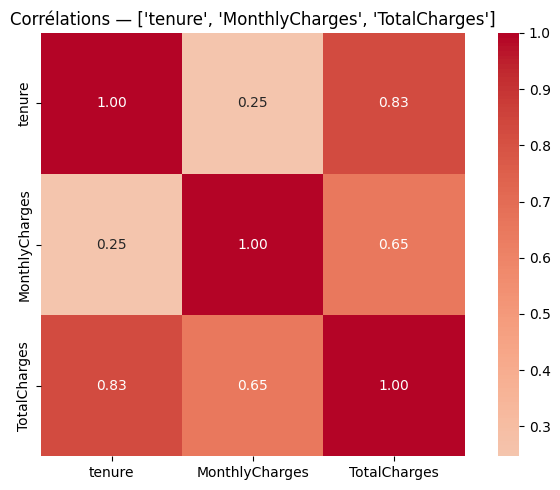


Colonne                        VIF
-----------------------------------
tenure                         6.3
MonthlyCharges                 3.4
TotalCharges                   8.1

→ Colonnes à fort VIF (> 5) : ['tenure', 'TotalCharges']

EDGE CASE : colonne dupliquée (TotalCharges_copie)
Colonnes continues détectées  : ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalCharges_copie']


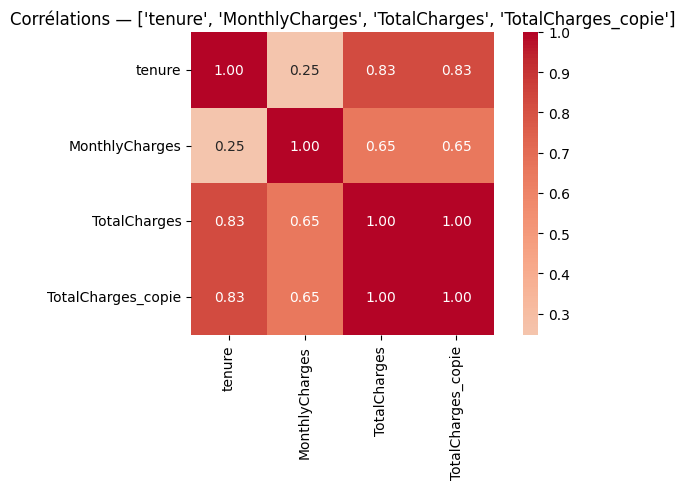


Colonne                        VIF
-----------------------------------
tenure                         6.3
MonthlyCharges                 3.4
TotalCharges                   inf
TotalCharges_copie             inf

→ Colonnes à fort VIF (> 5) : ['tenure', 'TotalCharges', 'TotalCharges_copie']

ADVERSARIAL : suppression de TotalCharges
Corrélation TotalCharges ~ tenure×MonthlyCharges : 1.000
→ Corrélation parfaite : TotalCharges = tenure × MonthlyCharges exactement.
  Aucun client n'a eu de remise ni de changement de forfait dans ce dataset.
  Supprimer TotalCharges ne perd aucune information.

VIF APRÈS suppression de TotalCharges :
Colonnes continues détectées  : ['tenure', 'MonthlyCharges']


c:\Users\Math34\Mathieu\Projets Ipssi\Ipssi_env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


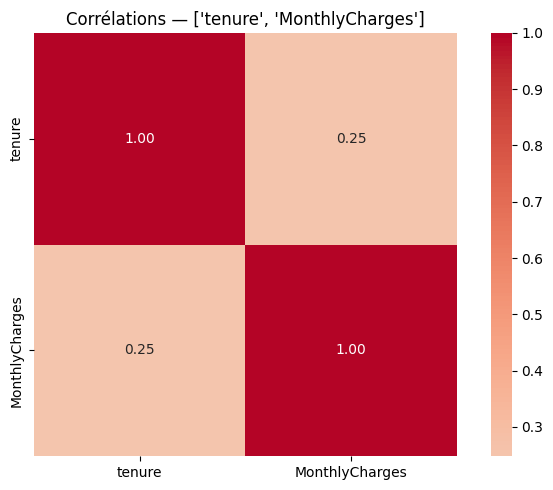


Colonne                        VIF
-----------------------------------
tenure                         2.6
MonthlyCharges                 2.6

→ Aucune colinéarité détectée.

→ Décision : supprimer TotalCharges.
  Corrélation = 1.000 → aucune info perdue.
  VIF de tenure et MonthlyCharges redescendent à ~2.6.
  Colonnes restantes : 38


In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def rapport_multicolinearite(df, colonnes_num):
    """Affiche la heatmap des corrélations et le VIF de chaque colonne numérique.
    Doit aider à décider quelle(s) colonne(s) redondante(s) supprimer.
    """
    sous_df = df[colonnes_num].copy().dropna().astype(float)

    # Détection automatique des colonnes continues vs binaires/ordinales
    # Continue = plus de 10 valeurs distinctes (binaire = 2, ordinal = 3)
    continues = [col for col in colonnes_num if sous_df[col].nunique() > 10]
    non_continues = [col for col in colonnes_num if col not in continues]
    print(f"Colonnes continues détectées  : {continues}")
    if non_continues:
        print(f"Colonnes binaires/ordinales   : {non_continues} (VIF moins pertinent sur ces colonnes)")

    # heatmap des corrélations
    plt.figure(figsize=(7, 5))
    sns.heatmap(sous_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title(f"Corrélations — {colonnes_num}")
    plt.tight_layout()
    plt.show()

    # VIF : mesure à quel point chaque variable est expliquée par les autres
    # VIF ≈ 1 → indépendante | 5–10 → redondante | > 10 → colinéarité forte
    print(f"\n{'Colonne':<25} {'VIF':>8}")
    print("-" * 35)
    X = sous_df.values
    vifs = {}
    for i, col in enumerate(colonnes_num):
        try:
            vif = variance_inflation_factor(X, i)
        except np.linalg.LinAlgError:
            # edge case : colinéarité parfaite → matrice singulière → algèbre plante
            vif = float("inf")
        # statsmodels peut aussi retourner nan ou inf sans lever d'exception
        if np.isnan(vif) or np.isinf(vif):
            vif = float("inf")
        vifs[col] = vif
        vif_str = "inf" if np.isinf(vif) else f"{vif:.1f}"
        print(f"{col:<25} {vif_str:>8}")

    a_supprimer = [col for col, v in vifs.items() if v > 5]
    if a_supprimer:
        print(f"\n→ Colonnes à fort VIF (> 5) : {a_supprimer}")
    else:
        print("\n→ Aucune colinéarité détectée.")

    return vifs


cols_num = ["tenure", "MonthlyCharges", "TotalCharges"]

# HAPPY PATH : heatmap + VIF sur les 3 colonnes numériques
print("HAPPY PATH")
vifs = rapport_multicolinearite(df_encoded, cols_num)

# EDGE CASE : colonne dupliquée → VIF explose vers l'infini
print("\nEDGE CASE : colonne dupliquée (TotalCharges_copie)")
df_test = df_encoded.copy()
df_test["TotalCharges_copie"] = df_test["TotalCharges"]
# TotalCharges et TotalCharges_copie sont identiques → corrélation = 1
# VIF explose à l'infini (ou fait planter sans le try/except ci-dessus)
rapport_multicolinearite(df_test, cols_num + ["TotalCharges_copie"])

# ADVERSARIAL : si on supprime TotalCharges, perd-on de l'info ?
print("\nADVERSARIAL : suppression de TotalCharges")

# Corrélation entre TotalCharges et tenure×MonthlyCharges pour mesurer l'info perdue
approx = df_encoded["tenure"] * df_encoded["MonthlyCharges"]
corr = df_encoded["TotalCharges"].corr(approx)
print(f"Corrélation TotalCharges ~ tenure×MonthlyCharges : {corr:.3f}")
if corr >= 0.999:
    print("→ Corrélation parfaite : TotalCharges = tenure × MonthlyCharges exactement.")
    print("  Aucun client n'a eu de remise ni de changement de forfait dans ce dataset.")
    print("  Supprimer TotalCharges ne perd aucune information.\n")
else:
    print(f"→ Corrélation < 1 ({corr:.3f}) : TotalCharges porte une info non reconstituable.")
    print("  Réfléchir avant de supprimer.\n")

# VIF après suppression : est-ce que ça règle le problème ?
print("VIF APRÈS suppression de TotalCharges :")
rapport_multicolinearite(df_encoded, ["tenure", "MonthlyCharges"])

# Décision finale
print("\n→ Décision : supprimer TotalCharges.")
print("  Corrélation = 1.000 → aucune info perdue.")
print("  VIF de tenure et MonthlyCharges redescendent à ~2.6.")
df_encoded = df_encoded.drop(columns=["TotalCharges"])
print(f"  Colonnes restantes : {df_encoded.shape[1]}")
